/tmp/ipykernel_26627/1340267176.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0060
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0012
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0012
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 9.6816e-04
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 8.9693e-04
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 8.3222e-04
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 7.0000e-04
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - loss: 6.3892e-04
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 6.4721e-04
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - loss: 6.6656e-04
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 5.4663e-04
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 6.5334e-04
Epoch 13/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - loss: 5.9165e-04
Epoch 14/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 5.4619e-04
Epoch 15/2

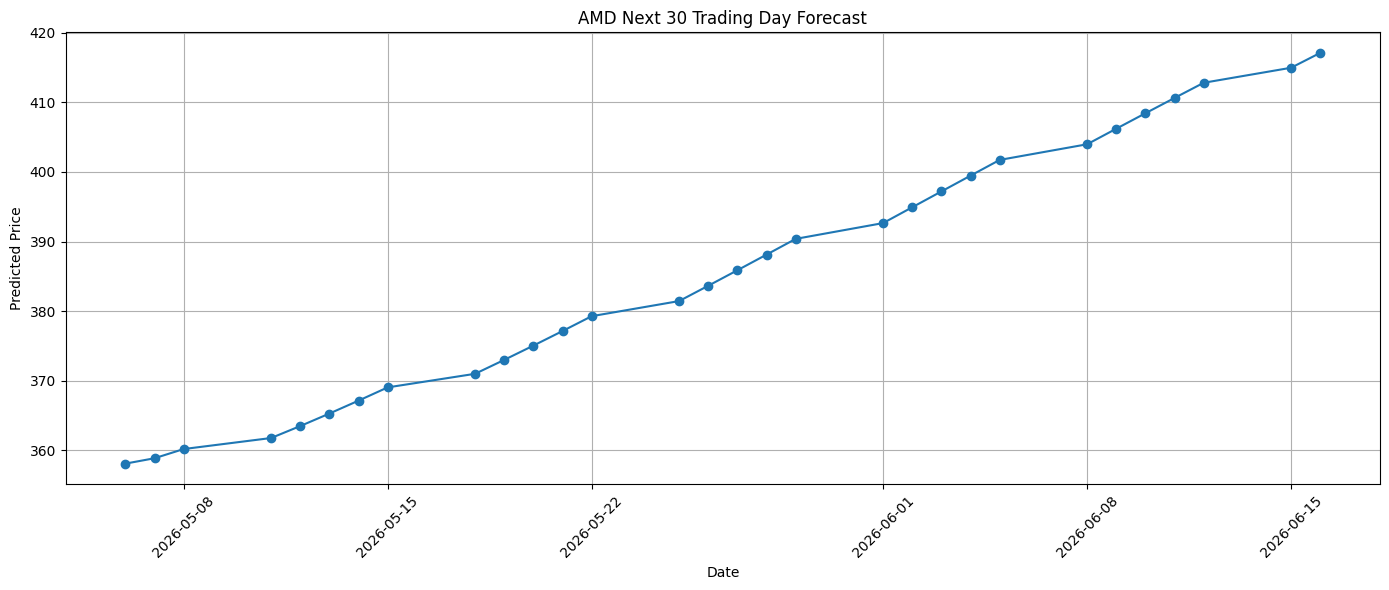

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


ticker = "AMD"
today = pd.Timestamp.today().normalize()
df = yf.download(
ticker,
start="2018-01-01",
end=today + pd.Timedelta(days=1)
)

data = df[['Close']].copy()

#scaling data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

#sequential

window = 60

X = []
y = []

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))


#building model

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")


#train
model.fit(X, y, epochs=20, batch_size=32)

#LAST 60 DAYS FOR FUTURE FORECAST

last_60 = scaled_data[-60:]
future_input = last_60.reshape(1,60,1)


# 7. NEXT 30 TRADING DAYS FORECAST
future_preds = []

for _ in range(30):
    pred = model.predict(future_input, verbose=0)
    future_preds.append(pred[0,0])

    future_input = np.append(
        future_input[:,1:,:],
        [[[pred[0,0]]]],
        axis=1
    )

#real qiymetlere qaytar

future_preds = np.array(future_preds).reshape(-1,1)
future_prices = scaler.inverse_transform(future_preds)

#next 30 days
future_dates = pd.bdate_range(
start=today + pd.Timedelta(days=1),
periods=30
)


# 10. RESULT TABLE

# ==========================================================

forecast_df = pd.DataFrame({
"Date": future_dates,
"Predicted_Close": future_prices.flatten()
})

print("\nNEXT 30 TRADING DAY FORECAST (AMD):\n")
print(forecast_df)


plt.figure(figsize=(14,6))
plt.plot(forecast_df["Date"], forecast_df["Predicted_Close"], marker="o")
plt.title("AMD Next 30 Trading Day Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Price")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()